In [34]:
import wandb
import matplotlib.pyplot as plt
import pandas as pd
import itertools
import math
import numpy as np
from tqdm import tqdm

In [38]:
def iqm(x):
    x = np.sort(np.array(x))
    n = len(x)
    q1 = n // 4
    q3 = n - q1
    return x[q1:q3].mean()

def stratified_iqm_ci(matrix, n_boot=100):
    # matrix: (seeds, tasks)

    def sample():
        idx = np.random.randint(0, matrix.shape[0], matrix.shape[0])
        return iqm(matrix[idx].mean(axis=1))

    stats = [sample() for _ in range(n_boot)]

    return np.mean(stats), np.percentile(stats, [5, 95])

In [7]:
api = wandb.Api()

wandb_runs = api.runs(
    "cl-probing/online-q-chunking",
    filters={
        "group": "final"
    }
)

print(len(wandb_runs))

200


In [47]:
metrics = [
    "eval/rh1/episode_reward",
    "eval/rh3/episode_reward",
    "eval/rh5/episode_reward",
    "eval/rh10/episode_reward",
    "eval/rh15/episode_reward",
]

all_hists = []

for run in tqdm(wandb_runs):
    config = run.config
    summary = run.summary

    hist = run.history(
        keys=["eval/full_chunk/episode_reward"],
        pandas=True,
    )

    idx = np.linspace(0, len(hist) - 1, 11).astype(int)

    hist = hist.iloc[idx]

    run_config = {
        "run_name": run.name,
        "seed": config.get("seed"),
        "env": config.get("env"),
        "action_chunk_length": config.get("action_chunk_length"),
        "random_replanning": config.get("random_replanning"),
        "target_entropy_coeff": config.get("target_entropy_coeff"),
    }

    run_summaries = {metric: summary.get(metric) for metric in metrics}

    for v, k in {**run_config, **run_summaries}.items():
        hist[v] = k

    all_hists.append(hist)

df = pd.concat(all_hists)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [02:25<00:00,  1.38it/s]


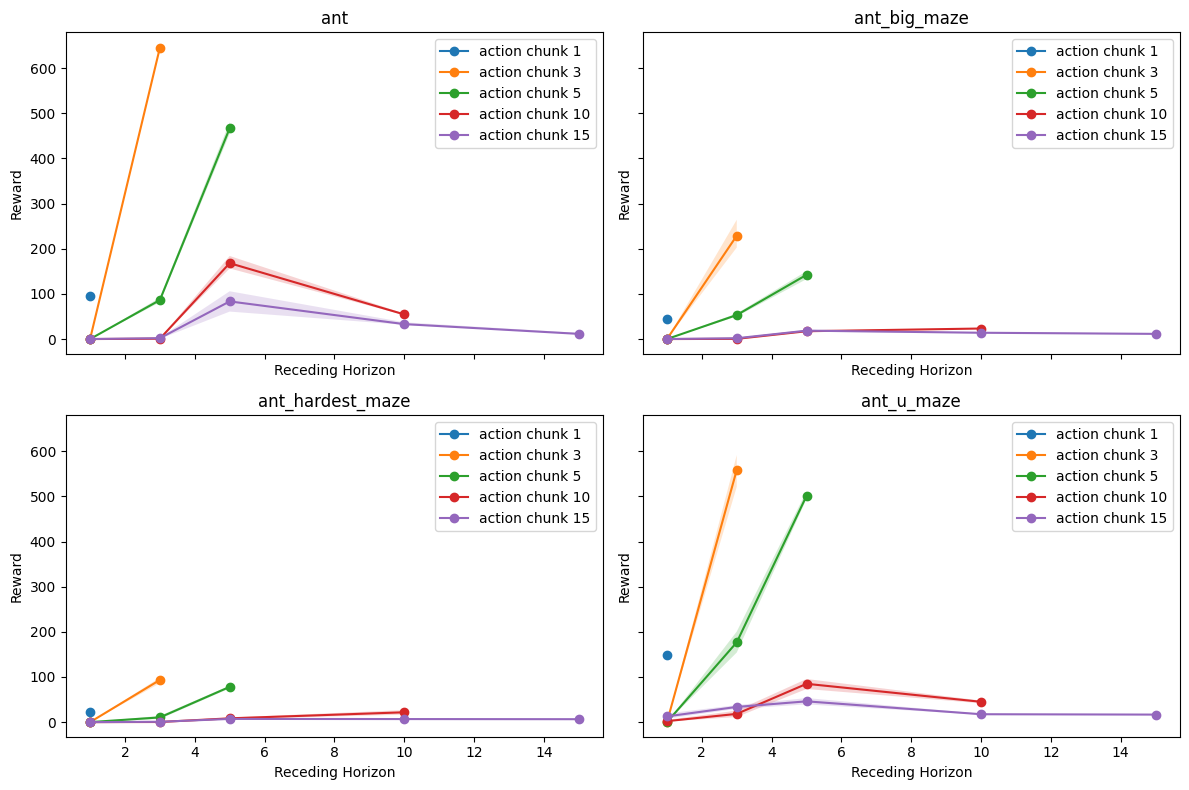

In [40]:
rand_replan = False
rh_metrics = [
    "eval/rh1/episode_reward",
    "eval/rh3/episode_reward",
    "eval/rh5/episode_reward",
    "eval/rh10/episode_reward",
    "eval/rh15/episode_reward",
]

envs = sorted(df["env"].unique())
n_envs = len(envs)

cols = 2
rows = math.ceil(n_envs / cols)

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows), sharex=True, sharey=True)

axes = axes.flatten()

for i, env in enumerate(envs):
    ax = axes[i]
    for acl in [1, 3, 5, 10, 15]:
        m = df[(df["action_chunk_length"] == acl) & (df["env"] == env) & (df["random_replanning"] == rand_replan)]
        m_last = m.loc[m.groupby("seed")["_step"].idxmax()]
        x = [1, 3, 5, 10, 15]
        rhs = [m[rh] for rh in rh_metrics]

        y = []
        ci_lows = []
        ci_highs = []
        
        for rh_list in rhs:
            if np.all(rh_list.to_numpy() == np.array(None)):
                iqm_, ci = np.nan, (np.nan, np.nan)
            else:
                iqm_, ci = stratified_iqm_ci(rh_list.to_numpy()[:, None])
                
            y.append(iqm_)
            ci_lows.append(ci[0])
            ci_highs.append(ci[1])
            
        ax.plot(x, y, marker="o", label=f"action chunk {acl}")

        ax.fill_between(
            x,
            ci_lows,
            ci_highs,
            alpha=0.2
        )

    ax.set_title(env)
    ax.set_xlabel("Receding Horizon")
    ax.set_ylabel("Reward")
    ax.legend()

plt.tight_layout()
plt.show()

6it [00:00, 43.03it/s]
6it [00:00, 18.69it/s]
6it [00:00, 47.38it/s]
6it [00:00, 47.00it/s]


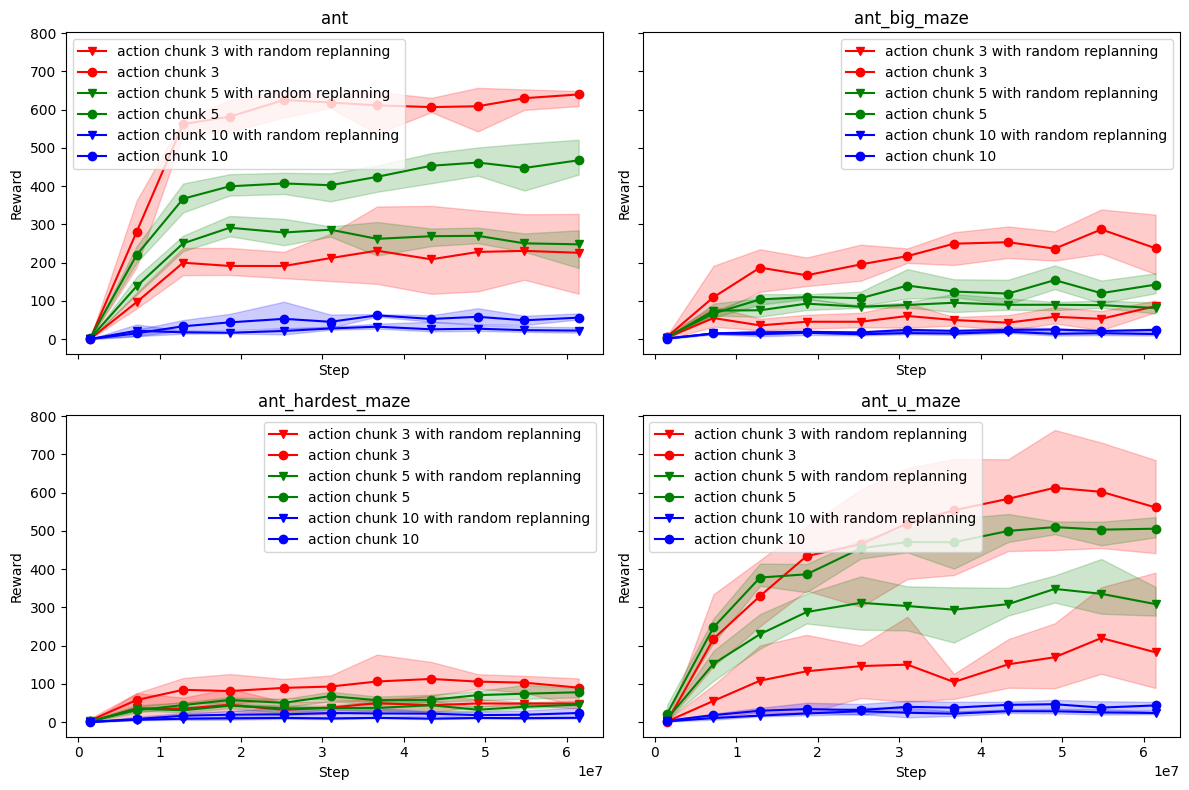

In [56]:
envs = sorted(df["env"].unique())
n_envs = len(envs)

cols = 2
rows = math.ceil(n_envs / cols)

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows), sharex=True, sharey=True)

axes = axes.flatten()

for i, env in enumerate(envs):
    ax = axes[i]
    for acl, rr in tqdm(itertools.product([3, 5, 10], [True, False])):
        m = df[(df["action_chunk_length"] == acl) & (df["env"] == env) & (df["random_replanning"] == rr)]
        x = m[m["seed"] == 0]["_step"].sort_values()
        
        reward_lists = [m[m["_step"] == step]["eval/full_chunk/episode_reward"] for step in x]

        y = []
        ci_lows = []
        ci_highs = []
        
        for reward_list in reward_lists:
            iqm_, ci = stratified_iqm_ci(reward_list.to_numpy()[:, None])
                
            y.append(iqm_)
            ci_lows.append(ci[0])
            ci_highs.append(ci[1])

        label = f"action chunk {acl}"
        marker = "o"
        if rr:
            label += " with random replanning"
            marker = "v"

        if acl == 3:
            color = "red"
        elif acl == 5:
            color = "green"
        else:
            color = "blue"
        ax.plot(x, y, marker=marker, label=label, c=color)

        ax.fill_between(
            x,
            ci_lows,
            ci_highs,
            alpha=0.2,
            color=color
        )

    ax.set_title(env)
    ax.set_xlabel("Step")
    ax.set_ylabel("Reward")
    ax.legend()

plt.tight_layout()
plt.show()